<a href="https://colab.research.google.com/github/KuChoiLab/2026_bomun_workshop/blob/main/Proteomics_practice/SomaScan/SomaScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download tools to use R in a Python runtime.
(As shown in the bottom right, the current environment is python3.)

In [ ]:
!pip install -q rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Download and extract the R library packages.

In [ ]:
!pip install -q gdown

import gdown

gdown.download(
    id="1Nxs1yX3LfgjtYSYdZ1lAxulGHzoPsGW5",
    output="SomaScan_library_packages.tar",
    quiet=False
)

!tar -xf SomaScan_library_packages.tar -C /content/

Downloading...
From (original): https://drive.google.com/uc?id=1Nxs1yX3LfgjtYSYdZ1lAxulGHzoPsGW5
From (redirected): https://drive.google.com/uc?id=1Nxs1yX3LfgjtYSYdZ1lAxulGHzoPsGW5&confirm=t&uuid=475cf98b-767a-41b2-a068-a0cbe5614740
To: /content/SomaScan_library_packages.tar
100%|██████████| 878M/878M [00:12<00:00, 71.8MB/s]


Set the R package library path and load the packages.

In [ ]:
%%R

lib <- "/content/content/drive/MyDrive/MOFA_test/R_libs"
.libPaths(c(lib, .libPaths()))

pkgs <- c(
"SomaDataIO","limma","clusterProfiler","org.Hs.eg.db","dplyr",
"ggplot2","tibble","ggrepel","pheatmap","openxlsx"
)

for(p in pkgs){
  suppressPackageStartupMessages(library(p, character.only = TRUE))
}

cat("loaded")

loaded

Download the raw intensity matrix, which is the output of MaxQuant.

In [ ]:
!pip install -q gdown

import gdown

file_id = "1JLRZizVgSFuhfHRm4K9H6B5iB24P4LFO"
output = "SomaScan_raw_intensity_matrix.adat"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1JLRZizVgSFuhfHRm4K9H6B5iB24P4LFO
To: /content/SomaScan_raw_intensity_matrix.adat
100%|██████████| 10.1M/10.1M [00:00<00:00, 107MB/s]


'SomaScan_raw_intensity_matrix.adat'

Download the metadata of the samples.

In [ ]:
!pip install -q gdown

import gdown

file_id = "1-cTPrVun8RzGNswYcFOPv3ZprddK-Uz4"
output = "SomaScan_metadata.txt"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1-cTPrVun8RzGNswYcFOPv3ZprddK-Uz4
To: /content/SomaScan_metadata.txt
100%|██████████| 2.03k/2.03k [00:00<00:00, 7.56MB/s]


'SomaScan_metadata.txt'

Load SomaScan ADAT and validate data integrity.

("Warning message: No SlideId_Subarray found in ADAT." This indicates that Slide/Subarray metadata are not present in the ADAT file, so rows are numbered sequentially. This is common in SomaScan data and does not affect downstream analyses.)

In [ ]:
%%R
adat <- read_adat("SomaScan_raw_intensity_matrix.adat")

stopifnot(is.soma_adat(adat))
stopifnot(is_intact_attr(adat))
getSomaScanVersion(adat)
adat <- SomaDataIO::col2rn(adat, "SampleID")

In addition: Warning messages:
1: No SlideId_Subarray found in ADAT. Rows numbered sequentially. 
2: `adat` already has row names. They will be over-written. 


In [ ]:
%%R
adat_qc <- adat %>%
  dplyr::filter(
    SampleType == "Plasma",
    RowCheck_PassFlag == "PASS"
  )

In [ ]:
%%R
analytes_all <- getAnalytes(adat_qc, rm.controls = FALSE)
analytes_no_control <- getAnalytes(adat_qc, rm.controls = TRUE)
feat <- getAnalyteInfo(adat_qc)

In [ ]:
%%R
nonhuman_seqid_raw <- feat %>%
  dplyr::filter(!is.na(Organism)) %>%
  dplyr::filter(Organism != "Human") %>%
  dplyr::pull(SeqId) %>%
  unique()

nonhuman_seqid_fixed <- gsub("-", ".", nonhuman_seqid_raw)
nonhuman_seq <- paste0("seq.", nonhuman_seqid_fixed)

In [ ]:
%%R
analytes <- setdiff(analytes_no_control, nonhuman_seq)

outlier_map <- calcOutlierMap(adat_qc[, analytes])

adat_qc_log2 <- adat_qc
adat_qc_log2[, analytes] <- log2(adat_qc_log2[, analytes])

expr_mat <- adat_qc %>%
  dplyr::select(all_of(analytes)) %>%
  as.matrix()

In [ ]:
%%R
expr_log <- log2(expr_mat + 1)

In [ ]:
%%R
sample_info <- read.delim(
  file = "SomaScan_metadata.txt",
  sep = "\t",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

sample_info <- sample_info %>%
  dplyr::rename(
    LabID = `Lab#`,
    SampleID = `Sample ID`
  )

meta_cols <- getMeta(adat_qc)
adat_meta <- adat_qc %>% dplyr::select(all_of(meta_cols))

adat_ids <- rownames(adat_qc)
sample_info2 <- sample_info %>%
  dplyr::filter(LabID %in% adat_ids) %>%
  dplyr::mutate(LabID = factor(LabID, levels = adat_ids)) %>%
  dplyr::arrange(LabID) %>%
  tibble::column_to_rownames("LabID")

meta_all <- dplyr::bind_cols(sample_info2, adat_meta)

meta <- meta_all %>%
  dplyr::select(Group, Sex, Age, PlateId, BatchID) %>%
  dplyr::mutate(
    Group = factor(Group, levels = c("Young", "Old")),
    Sex   = factor(Sex)
  )

In [ ]:
%%R
design <- model.matrix(~ 0 + Group, data = meta)
colnames(design) <- gsub("^Group", "", colnames(design))

fit <- limma::lmFit(t(expr_log), design)
cont <- limma::makeContrasts(Old_vs_Young = Old - Young, levels = design)
fit2 <- limma::contrasts.fit(fit, cont)
fit2 <- limma::eBayes(fit2)

In [ ]:
%%R
res <- limma::topTable(
  fit2,
  coef = "Old_vs_Young",
  number = Inf,
  adjust.method = "BH"
) %>%
  tibble::rownames_to_column("Analyte")

adat_anno <- suppressMessages(SomaDataIO::getAnalyteInfo(adat_qc))

anno_map <- adat_anno %>%
  dplyr::select(
    Analyte  = AptName,
    ENTREZID = `Entrez.Gene.ID`,
    SYMBOL   = `Entrez.Gene.Symbol`
  ) %>%
  dplyr::mutate(
    Target = dplyr::if_else(
      !is.na(SYMBOL) & SYMBOL != "",
      SYMBOL,
      ENTREZID
    )
  )

res <- res %>%
  dplyr::left_join(anno_map %>% dplyr::select(Analyte, Target), by = "Analyte")

FDR_CUTOFF <- 0.1
LFC_CUTOFF <- log2(1.5)

res2 <- res %>%
  dplyr::mutate(
    is_diff = (adj.P.Val <= FDR_CUTOFF) & (abs(logFC) > LFC_CUTOFF),
    neglog10FDR = -log10(pmax(adj.P.Val, .Machine$double.xmin))
  )

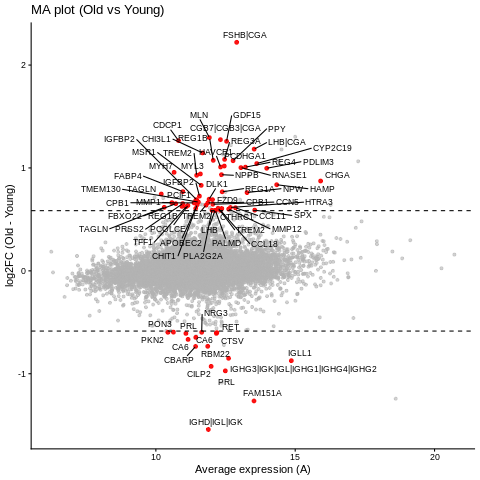

In [ ]:
%%R
group_colors <- c(Young = "red2", Old = "blue2")

p_ma <- ggplot(res2, aes(x = AveExpr, y = logFC)) +
  geom_point(color = "grey70", alpha = 0.6, size = 1.2) +
  geom_point(
    data = res2 %>% dplyr::filter(is_diff),
    aes(x = AveExpr, y = logFC),
    color = "red",
    alpha = 0.9,
    size = 1.6
  ) +
  ggrepel::geom_text_repel(
    data = res2 %>% dplyr::filter(is_diff),
    aes(label = Target),
    size = 3,
    max.overlaps = Inf
  ) +
  theme_classic() +
  labs(
    title = "MA plot (Old vs Young)",
    x = "Average expression (A)",
    y = "log2FC (Old - Young)"
  ) +
  geom_hline(yintercept = c(-LFC_CUTOFF, LFC_CUTOFF), linetype = "dashed")

print(p_ma)

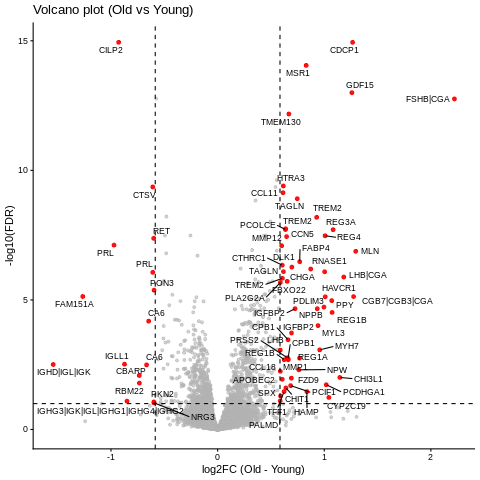

In [ ]:
%%R
p_vol <- ggplot(res2, aes(x = logFC, y = neglog10FDR)) +
  geom_point(color = "grey70", alpha = 0.6, size = 1.2) +
  geom_point(
    data = res2 %>% dplyr::filter(is_diff),
    aes(x = logFC, y = neglog10FDR),
    color = "red",
    alpha = 0.9,
    size = 1.6
  ) +
  ggrepel::geom_text_repel(
    data = res2 %>% dplyr::filter(is_diff),
    aes(label = Target),
    size = 3,
    max.overlaps = Inf
  ) +
  theme_classic() +
  labs(
    title = "Volcano plot (Old vs Young)",
    x = "log2FC (Old - Young)",
    y = "-log10(FDR)"
  ) +
  geom_hline(yintercept = -log10(FDR_CUTOFF), linetype = "dashed") +
  geom_vline(xintercept = c(-LFC_CUTOFF, LFC_CUTOFF), linetype = "dashed")

print(p_vol)

In [ ]:
diff_ids <- intersect(
  res2 %>% dplyr::filter(is_diff) %>% dplyr::pull(Analyte),
  colnames(expr_log)
)

mat <- t(expr_log[rownames(meta), diff_ids, drop = FALSE])
mat_z <- t(scale(t(mat)))

target_vec <- anno_map$Target[match(rownames(mat_z), anno_map$Analyte)]
target_vec[is.na(target_vec) | target_vec == ""] <- rownames(mat_z)[is.na(target_vec) | target_vec == ""]
rownames(mat_z) <- make.unique(as.character(target_vec))

ann_col <- meta[colnames(mat_z), "Group", drop = FALSE]

breaks_z <- seq(-2, 2, length.out = 101)
colors_z <- colorRampPalette(c("#D55E00", "white", "#0072B2"))(100)

pheatmap::pheatmap(
  mat_z,
  annotation_col = ann_col,
  annotation_colors = list(Group = group_colors),
  breaks = breaks_z,
  color = colors_z,
  show_rownames = TRUE,
  fontsize_row = 6,
  fontsize_col = 6,
  main = paste0("Differential proteins (n=", nrow(mat_z), ")")
)

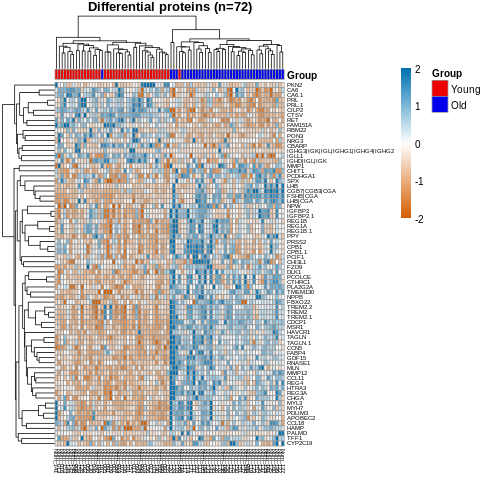

In [ ]:
%%R
diff_ids <- intersect(
  res2 %>% dplyr::filter(is_diff) %>% dplyr::pull(Analyte),
  colnames(expr_log)
)

mat <- t(expr_log[rownames(meta), diff_ids, drop = FALSE])
mat_z <- t(scale(t(mat)))

target_vec <- anno_map$Target[match(rownames(mat_z), anno_map$Analyte)]
target_vec[is.na(target_vec) | target_vec == ""] <- rownames(mat_z)[is.na(target_vec) | target_vec == ""]
rownames(mat_z) <- make.unique(as.character(target_vec))

ann_col <- meta[colnames(mat_z), "Group", drop = FALSE]

breaks_z <- seq(-2, 2, length.out = 101)
colors_z <- colorRampPalette(c("#D55E00", "white", "#0072B2"))(100)

pheatmap::pheatmap(
  mat_z,
  annotation_col = ann_col,
  annotation_colors = list(Group = group_colors),
  breaks = breaks_z,
  color = colors_z,
  show_rownames = TRUE,
  fontsize_row = 6,
  fontsize_col = 6,
  main = paste0("Differential proteins (n=", nrow(mat_z), ")")
)

In [ ]:
%%R
diff_ranked_by_abs_t <- res2 %>%
  dplyr::filter(is_diff) %>%
  dplyr::arrange(desc(abs(t))) %>%
  dplyr::select(
    Target,
    AveExpr,
    logFC,
    adj.P.Val,
    t
  )